# Qwen3.5-4B candidate readouts and thinking budgets

This notebook answers four related questions for the $N=8$, $K=3$
noisy-source candidate comparison from notebooks 01, 05, and 06.

1. Is the original counterbalanced A/B/C candidate probe above three-way chance?
2. What happens when Qwen instead emits the winning integer or `FINAL: TIE`?
3. What happens with an immediate `FINAL: ` readout and zero generated reasoning tokens?
4. What happens when Qwen native thinking is enabled under an explicit token cap?

Existing artifacts are used where they answer the question. The missing native-thinking
arm and matched controls were run on repeat 4, which was not used by notebooks 05 or 06.
All matched arms see only public rules, raw sets/reports, and candidate identities.
Evaluator-derived memberships, counts, likelihoods, posteriors, and targets remain hidden.


In [1]:
from __future__ import annotations

import json
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the MATS repository.")


def load_jsonl(path: Path) -> list[dict[str, object]]:
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


def markdown_table(headers: list[str], rows: list[list[object]]) -> None:
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


def wilson(successes: int, n: int, z: float = 1.959963984540054) -> tuple[float, float]:
    p = successes / n
    denominator = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denominator
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denominator
    return center - half, center + half


def upper_binomial_p(successes: int, n: int, chance: float) -> float:
    return sum(
        math.comb(n, k) * chance**k * (1 - chance) ** (n - k)
        for k in range(successes, n + 1)
    )


def balanced_accuracy(rows: list[dict[str, object]], *, correct_key: str) -> float:
    targets = sorted({str(row["normative_absolute"]) for row in rows})
    recalls = []
    for target in targets:
        group = [row for row in rows if str(row["normative_absolute"]) == target]
        recalls.append(sum(bool(row[correct_key]) for row in group) / len(group))
    return sum(recalls) / len(recalls)


def exact_mcnemar(
    left: list[dict[str, object]], right: list[dict[str, object]]
) -> tuple[int, int, float]:
    left_by_id = {str(row["example_id"]): bool(row["correct"]) for row in left}
    right_by_id = {str(row["example_id"]): bool(row["correct"]) for row in right}
    assert left_by_id.keys() == right_by_id.keys()
    left_only = sum(left_by_id[key] and not right_by_id[key] for key in left_by_id)
    right_only = sum(right_by_id[key] and not left_by_id[key] for key in left_by_id)
    discordant = left_only + right_only
    if not discordant:
        return left_only, right_only, 1.0
    tail = sum(
        math.comb(discordant, k)
        for k in range(min(left_only, right_only) + 1)
    ) / 2**discordant
    return left_only, right_only, min(1.0, 2 * tail)


def result_stats(rows: list[dict[str, object]]) -> dict[str, object]:
    successes = sum(bool(row["correct"]) for row in rows)
    non_ties = [row for row in rows if str(row["normative_absolute"]) != "tie"]
    non_tie_successes = sum(bool(row["correct"]) for row in non_ties)
    low, high = wilson(successes, len(rows))
    nt_low, nt_high = wilson(non_tie_successes, len(non_ties))
    return {
        "n": len(rows),
        "successes": successes,
        "accuracy": successes / len(rows),
        "ci": (low, high),
        "p_three_way": upper_binomial_p(successes, len(rows), 1 / 3),
        "non_tie_n": len(non_ties),
        "non_tie_successes": non_tie_successes,
        "non_tie_accuracy": non_tie_successes / len(non_ties),
        "non_tie_ci": (nt_low, nt_high),
        "p_two_way": upper_binomial_p(non_tie_successes, len(non_ties), 1 / 2),
    }


REPO_ROOT = find_repo_root()
MINIMAL_DIR = REPO_ROOT / "artifacts" / "minimal_noisy_source"
SINGLE_DIR = REPO_ROOT / "artifacts" / "single_call_candidate"
FILLER_DIR = REPO_ROOT / "artifacts" / "filler_token_probe"
SIZE_DIR = REPO_ROOT / "artifacts" / "model_size_study"
BUDGET_DIR = REPO_ROOT / "artifacts" / "thinking_budget_candidate"
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
abc = load_jsonl(MINIMAL_DIR / "qwen_counterbalanced_results.jsonl")
abc_candidates = [row for row in abc if row["probe_kind"] == "candidate"]
notebook05_test = load_jsonl(SINGLE_DIR / "test_system_reason_results.jsonl")
notebook06_validation = load_jsonl(FILLER_DIR / "validation_selected_results.jsonl")
direct_heldout = load_jsonl(SIZE_DIR / "direct_4b_results.jsonl")

repeat4 = {
    "direct_f0": load_jsonl(BUDGET_DIR / "repeat4_direct_f0_results.jsonl"),
    "filler11": load_jsonl(BUDGET_DIR / "repeat4_filler11_results.jsonl"),
    "visible": load_jsonl(BUDGET_DIR / "repeat4_visible_deliberation_results.jsonl"),
    "thinking": load_jsonl(BUDGET_DIR / "repeat4_native_thinking_8192_results.jsonl"),
}
manifests = {
    name: json.loads((BUDGET_DIR / filename).read_text())
    for name, filename in {
        "direct_f0": "repeat4_direct_f0_manifest.json",
        "filler11": "repeat4_filler11_manifest.json",
        "visible": "repeat4_visible_deliberation_manifest.json",
        "thinking": "repeat4_native_thinking_8192_manifest.json",
    }.items()
}

expected_ids = {str(row["example_id"]) for row in repeat4["visible"]}
assert len(expected_ids) == 56
assert all({str(row["example_id"]) for row in rows} == expected_ids for rows in repeat4.values())
assert all(int(row["repeat"]) == 4 for rows in repeat4.values() for row in rows)
assert manifests["direct_f0"]["protocol"]["generated_reasoning_tokens"] == 0
assert manifests["filler11"]["protocol"]["generated_reasoning_tokens"] == 0
assert manifests["visible"]["variant"]["enable_thinking"] is False
assert manifests["visible"]["variant"]["effective_max_new_tokens"] == 1024
assert manifests["thinking"]["variant"]["enable_thinking"] is True
assert manifests["thinking"]["variant"]["effective_max_new_tokens"] == 8192

visible_messages = {str(row["example_id"]): row["messages"] for row in repeat4["visible"]}
assert all(
    row["messages"] == visible_messages[str(row["example_id"])]
    for row in repeat4["thinking"]
)
assert all(
    bool(row["parse_success"]) == bool(row["thinking_completed"])
    for row in repeat4["thinking"]
)
assert all(
    bool(row["hit_max_new_tokens"]) == (not bool(row["parse_success"]))
    for row in repeat4["thinking"]
)
print("Matched examples, prompt equality, token caps, and strict thinking completion checks: PASS")


Matched examples, prompt equality, token caps, and strict thinking completion checks: PASS


## 1. Original A/B/C candidate probe

Notebook 01 scores all six mappings between the semantic answers
`left`, `right`, `tie` and the literal labels A/B/C, then aggregates the
semantic probability. This is the correct version to compare with $1/3$;
a single canonical label order is confounded by Qwen's label preference.

The all-repeat table is descriptive because the notebook did not reserve a
prompt-selection split. The repeat-4 table shows the same saved probe on the
split used for the new matched experiment.


In [3]:
abc_rows = []
for prompt_variant in ("older", "newer"):
    rows = [row for row in abc_candidates if row["prompt_variant"] == prompt_variant]
    successes = sum(bool(row["counterbalanced_correct"]) for row in rows)
    target_recalls = []
    for target in ("left", "right", "tie"):
        group = [row for row in rows if row["normative_semantic_choice"] == target]
        target_recalls.append(
            sum(bool(row["counterbalanced_correct"]) for row in group) / len(group)
        )
    nonhalf = [row for row in rows if float(row["reliability"]) != 0.5]
    nonhalf_successes = sum(bool(row["counterbalanced_correct"]) for row in nonhalf)
    predictions = Counter(str(row["predicted_semantic_choice"]) for row in rows)
    abc_rows.append(
        [
            prompt_variant,
            f"{successes}/{len(rows)} ({successes / len(rows):.1%})",
            f"{sum(target_recalls) / 3:.1%}",
            f"{upper_binomial_p(successes, len(rows), 1 / 3):.2g}",
            f"{nonhalf_successes}/{len(nonhalf)} ({nonhalf_successes / len(nonhalf):.1%})",
            f"{upper_binomial_p(nonhalf_successes, len(nonhalf), 1 / 3):.2g}",
            f"{predictions['left']}/{predictions['right']}/{predictions['tie']}",
        ]
    )
markdown_table(
    [
        "prompt",
        "all accuracy",
        "class-balanced",
        "one-sided p vs 1/3",
        "excluding r=0.5",
        "p vs 1/3",
        "pred left/right/tie",
    ],
    abc_rows,
)

repeat4_abc_rows = []
for prompt_variant in ("older", "newer"):
    rows = [
        row for row in abc_candidates
        if row["prompt_variant"] == prompt_variant and int(row["repeat"]) == 4
    ]
    successes = sum(bool(row["counterbalanced_correct"]) for row in rows)
    repeat4_abc_rows.append(
        [
            prompt_variant,
            f"{successes}/{len(rows)} ({successes / len(rows):.1%})",
            f"{upper_binomial_p(successes, len(rows), 1 / 3):.3f}",
        ]
    )
display(Markdown("**Repeat 4 only**"))
markdown_table(["prompt", "accuracy", "one-sided p vs 1/3"], repeat4_abc_rows)


| prompt | all accuracy | class-balanced | one-sided p vs 1/3 | excluding r=0.5 | p vs 1/3 | pred left/right/tie |
| --- | --- | --- | --- | --- | --- | --- |
| older | 409/896 (45.6%) | 44.4% | 1.5e-14 | 309/768 (40.2%) | 3.7e-05 | 529/111/256 |
| newer | 373/896 (41.6%) | 33.1% | 1.3e-07 | 245/768 (31.9%) | 0.81 | 94/2/800 |

**Repeat 4 only**

| prompt | accuracy | one-sided p vs 1/3 |
| --- | --- | --- |
| older | 24/56 (42.9%) | 0.087 |
| newer | 16/56 (28.6%) | 0.814 |

The majority target is `tie` (389/896 = 43.4%), so raw $1/3$ is not the only
useful reference. The older A/B/C wording has a modest above-$1/3$ aggregate
signal over all repeats and remains above $1/3$ after removing the automatic
all-tie $r=0.5$ condition, but its 45.6% overall accuracy is only 2.2 points
above the majority-target baseline. The newer wording does not show robust
signal: its class-balanced accuracy is essentially chance, it predicts
`right` only 2 times in 896 examples, and its non-$0.5$ accuracy is below
$1/3$. Neither prompt is significant on repeat 4 alone. Thus “better than
chance” is true only in a narrow aggregate sense for the older prompt; it is
not evidence of a robust three-way decoder.


## 2. Exact integer/TIE output with visible deliberation

Notebook 05 disables native thinking but allows one visible derivation under
a 1,024-token continuation cap and parses the last `FINAL: 2`, `FINAL: 7`,
or `FINAL: TIE`. The held-out repeats 2--3 result is compared with the new
repeat-4 replication below.


In [4]:
visible_rows = []
for label, rows in (
    ("notebook 05 held-out (repeats 2-3)", notebook05_test),
    ("new matched repeat 4", repeat4["visible"]),
):
    stats = result_stats(rows)
    visible_rows.append(
        [
            label,
            f"{stats['successes']}/{stats['n']} ({stats['accuracy']:.1%})",
            f"{stats['ci'][0]:.1%}-{stats['ci'][1]:.1%}",
            f"{stats['p_three_way']:.2g}",
            f"{sum(bool(row['parse_success']) for row in rows) / len(rows):.1%}",
        ]
    )
markdown_table(
    ["split", "accuracy", "95% Wilson CI", "one-sided p vs 1/3", "answer rate"],
    visible_rows,
)


| split | accuracy | 95% Wilson CI | one-sided p vs 1/3 | answer rate |
| --- | --- | --- | --- | --- |
| notebook 05 held-out (repeats 2-3) | 107/112 (95.5%) | 90.0%-98.1% | 1.6e-44 | 100.0% |
| new matched repeat 4 | 54/56 (96.4%) | 87.9%-99.0% | 1.2e-23 | 100.0% |

The exact-candidate readout with visible deliberation is decisively above
chance: 107/112 (95.5%) on notebook 05's held-out test and 54/56 (96.4%)
on repeat 4. The improvement is not merely a different answer vocabulary;
notebook 05's answer-only pilot was much weaker. The operative change is
the prompt/readout plus a generated visible derivation.


## 3. Zero generated reasoning tokens

Notebook 06 prefills an exact assistant `FINAL: ` prefix and scores one
token over `2`, `7`, and `=`. It generates no scratchpad and does not enable
thinking. Because this model never selects `=`, both baselines matter:
overall three-answer accuracy versus $1/3$, and non-tie candidate accuracy
versus $1/2$.


In [5]:
direct_conditions = [
    ("notebook 06 selected _ x11, validation repeat 1", notebook06_validation),
    ("direct F=0, held-out repeats 2-3", direct_heldout),
    ("direct F=0, repeat 4", repeat4["direct_f0"]),
    ("selected _ x11, repeat 4", repeat4["filler11"]),
]
direct_rows = []
for label, rows in direct_conditions:
    stats = result_stats(rows)
    direct_rows.append(
        [
            label,
            f"{stats['successes']}/{stats['n']} ({stats['accuracy']:.1%})",
            f"{stats['p_three_way']:.3f}",
            (
                f"{stats['non_tie_successes']}/{stats['non_tie_n']} "
                f"({stats['non_tie_accuracy']:.1%})"
            ),
            f"{stats['p_two_way']:.3f}",
        ]
    )
markdown_table(
    [
        "condition",
        "all-case accuracy",
        "p vs 1/3",
        "non-tie accuracy",
        "p vs 1/2",
    ],
    direct_rows,
)


| condition | all-case accuracy | p vs 1/3 | non-tie accuracy | p vs 1/2 |
| --- | --- | --- | --- | --- |
| notebook 06 selected _ x11, validation repeat 1 | 25/56 (44.6%) | 0.051 | 25/40 (62.5%) | 0.077 |
| direct F=0, held-out repeats 2-3 | 31/112 (27.7%) | 0.916 | 31/60 (51.7%) | 0.449 |
| direct F=0, repeat 4 | 18/56 (32.1%) | 0.624 | 18/40 (45.0%) | 0.785 |
| selected _ x11, repeat 4 | 18/56 (32.1%) | 0.624 | 18/40 (45.0%) | 0.785 |

The original selected notebook-06 validation point is numerically above
chance (25/56 overall; 25/40 on non-ties), but neither one-sided test reaches
0.05. It also does not replicate: direct $F=0$ is 31/60 = 51.7% on non-ties
in held-out repeats 2--3, and both $F=0$ and the selected 11-underscore
suffix score 18/40 = 45.0% on repeat 4. With zero generated reasoning
tokens, there is no reliable above-chance evidence.


## 4. Native thinking with an explicit 8,192-token cap

The missing arm uses exactly the same messages and exact-integer parser as
the repeat-4 visible-deliberation arm, changing only native thinking and the
total continuation cap. A response counts only if the model closes
`</think>` and emits a valid `FINAL` afterward. Mentions of `FINAL` inside a
truncated trace do not count. Completion-only smoke runs on one repeat-4
example per reliability showed that 2,048 and 4,096 tokens were too short;
8,192 was then fixed for the complete 56-example run. The repeat-4 p-values
are therefore descriptive rather than preregistered confirmatory tests.


| arm | end-to-end accuracy | 95% Wilson CI | p vs 1/3 | answer rate | cap-hit rate |
| --- | --- | --- | --- | --- | --- |
| visible deliberation, native thinking off, cap 1,024 | 54/56 (96.4%) | 87.9%-99.0% | 1.2e-23 | 100.0% | 0.0% |
| native thinking on, cap 8,192 | 42/56 (75.0%) | 62.3%-84.5% | 2.2e-10 | 75.0% | 25.0% |

Native thinking non-tie: 30/40 = 75.0%; one-sided p vs 1/2 = 0.001111
Completed native-thinking answers correct: 42/42
Exact McNemar: visible-only correct=13, thinking-only correct=1, two-sided p=0.001831


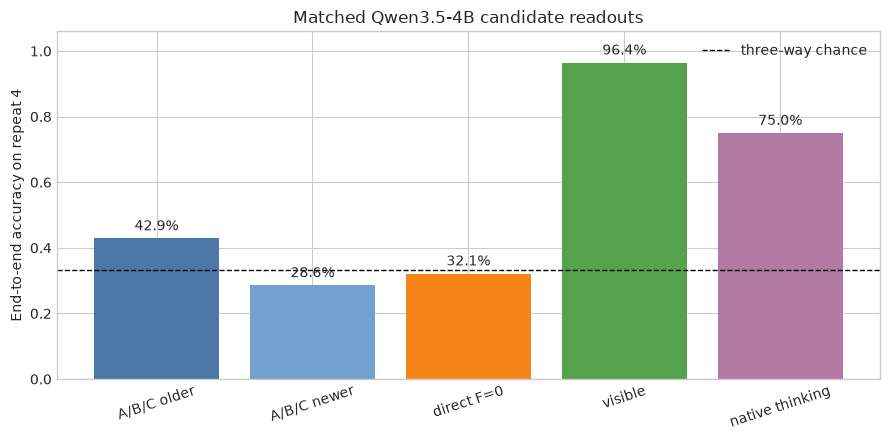

In [6]:
thinking_stats = result_stats(repeat4["thinking"])
visible_stats = result_stats(repeat4["visible"])
completed = [row for row in repeat4["thinking"] if row["parse_success"]]
cap_hits = [row for row in repeat4["thinking"] if row["hit_max_new_tokens"]]
visible_only, thinking_only, mcnemar_p = exact_mcnemar(
    repeat4["visible"], repeat4["thinking"]
)

markdown_table(
    [
        "arm",
        "end-to-end accuracy",
        "95% Wilson CI",
        "p vs 1/3",
        "answer rate",
        "cap-hit rate",
    ],
    [
        [
            "visible deliberation, native thinking off, cap 1,024",
            f"{visible_stats['successes']}/56 ({visible_stats['accuracy']:.1%})",
            f"{visible_stats['ci'][0]:.1%}-{visible_stats['ci'][1]:.1%}",
            f"{visible_stats['p_three_way']:.2g}",
            "100.0%",
            "0.0%",
        ],
        [
            "native thinking on, cap 8,192",
            f"{thinking_stats['successes']}/56 ({thinking_stats['accuracy']:.1%})",
            f"{thinking_stats['ci'][0]:.1%}-{thinking_stats['ci'][1]:.1%}",
            f"{thinking_stats['p_three_way']:.2g}",
            f"{len(completed) / 56:.1%}",
            f"{len(cap_hits) / 56:.1%}",
        ],
    ],
)
print(
    f"Native thinking non-tie: {thinking_stats['non_tie_successes']}/"
    f"{thinking_stats['non_tie_n']} = {thinking_stats['non_tie_accuracy']:.1%}; "
    f"one-sided p vs 1/2 = {thinking_stats['p_two_way']:.4g}"
)
print(f"Completed native-thinking answers correct: {sum(row['correct'] for row in completed)}/{len(completed)}")
print(
    f"Exact McNemar: visible-only correct={visible_only}, "
    f"thinking-only correct={thinking_only}, two-sided p={mcnemar_p:.4g}"
)

labels = ["A/B/C older", "A/B/C newer", "direct F=0", "visible", "native thinking"]
matched_abc = []
for variant in ("older", "newer"):
    rows = [
        row for row in abc_candidates
        if row["prompt_variant"] == variant and int(row["repeat"]) == 4
    ]
    matched_abc.append(sum(bool(row["counterbalanced_correct"]) for row in rows) / len(rows))
accuracies = [
    *matched_abc,
    result_stats(repeat4["direct_f0"])["accuracy"],
    visible_stats["accuracy"],
    thinking_stats["accuracy"],
]
fig, axis = plt.subplots(figsize=(9, 4.5))
bars = axis.bar(labels, accuracies, color=["#4c78a8", "#72a0cf", "#f58518", "#54a24b", "#b279a2"])
axis.axhline(1 / 3, color="black", linestyle="--", linewidth=1, label="three-way chance")
axis.set_ylim(0, 1.06)
axis.set_ylabel("End-to-end accuracy on repeat 4")
axis.set_title("Matched Qwen3.5-4B candidate readouts")
axis.tick_params(axis="x", rotation=18)
axis.legend()
for bar, value in zip(bars, accuracies):
    axis.text(bar.get_x() + bar.get_width() / 2, value + 0.025, f"{value:.1%}", ha="center")
fig.tight_layout()
plt.show()


Native thinking is decisively above chance end to end: 42/56 = 75.0%
overall, and 30/40 = 75.0% on non-ties against a 50% baseline. Every one
of the 42 completed answers is correct. However, 14/56 traces hit the
8,192-token cap without producing an answer, so native thinking is
significantly worse than the shorter visible-deliberation arm on these
matched examples (exact McNemar $p=0.00183$).

The practical conclusion is not simply “more thinking is better.” A modest,
explicitly requested visible derivation is highly effective; native thinking
also computes correct answers when it terminates, but frequently loops past
a very large budget.


## Reproduction

The new artifacts were produced with the local pinned Qwen3.5-4B snapshot:

```bash
uv run --frozen python scripts/run_filler_sweep.py \
  --output artifacts/thinking_budget_candidate/repeat4_direct_f0_results.jsonl \
  --manifest artifacts/thinking_budget_candidate/repeat4_direct_f0_manifest.json \
  --repeats 4 --fillers underscore --f-min 0 --f-max 0 --batch-size 32 --overwrite

uv run --frozen python scripts/run_filler_sweep.py \
  --output artifacts/thinking_budget_candidate/repeat4_filler11_results.jsonl \
  --manifest artifacts/thinking_budget_candidate/repeat4_filler11_manifest.json \
  --repeats 4 --fillers underscore --f-min 11 --f-max 11 --batch-size 32 --overwrite

uv run --frozen python scripts/run_single_call_candidate.py \
  --output artifacts/thinking_budget_candidate/repeat4_visible_deliberation_results.jsonl \
  --manifest artifacts/thinking_budget_candidate/repeat4_visible_deliberation_manifest.json \
  --repeats 4 --variant number_system_reason --max-new-tokens 1024 \
  --batch-size 4 --overwrite

uv run --frozen python scripts/run_single_call_candidate.py \
  --output artifacts/thinking_budget_candidate/repeat4_native_thinking_8192_results.jsonl \
  --manifest artifacts/thinking_budget_candidate/repeat4_native_thinking_8192_manifest.json \
  --repeats 4 --variant number_system_reason --enable-thinking \
  --max-new-tokens 8192 --batch-size 4 --batch-by-reliability --overwrite
```
